  Найдено pc-элементов: 10922
  Найдено pc-элементов: 1249
Всего знаков препинания в корпусе: 12171


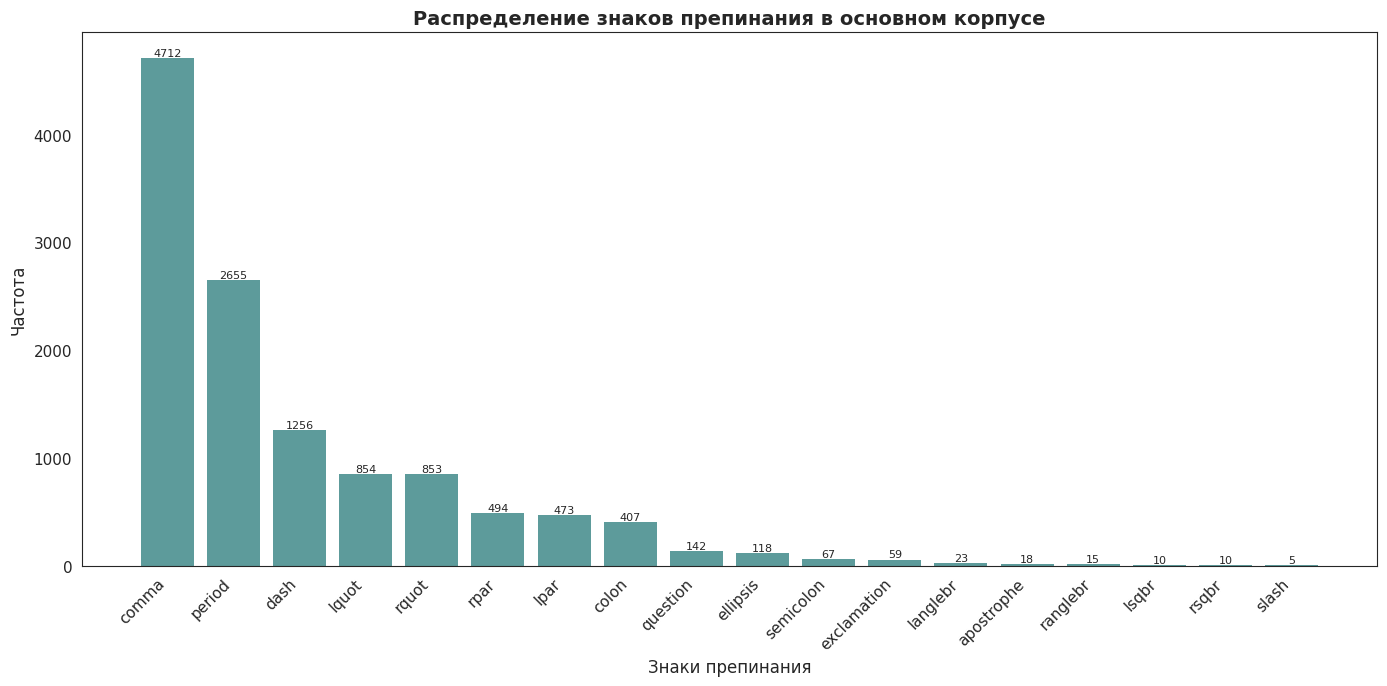

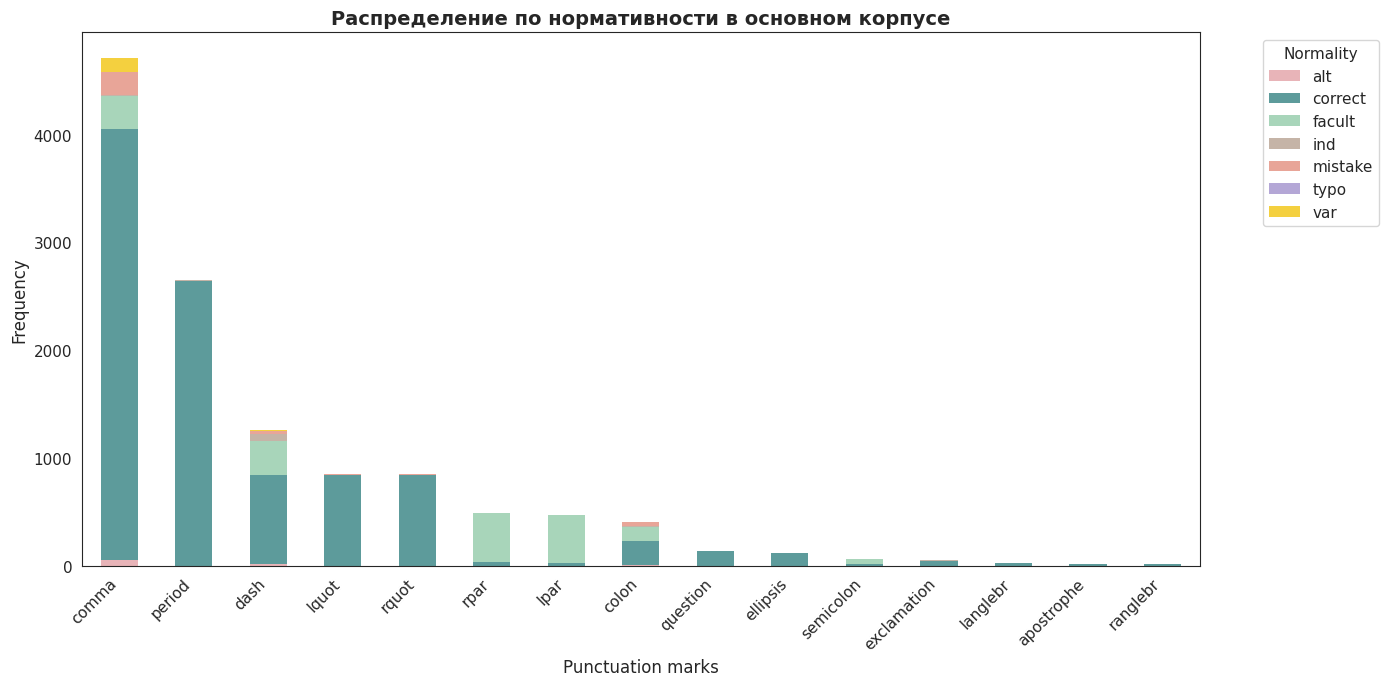

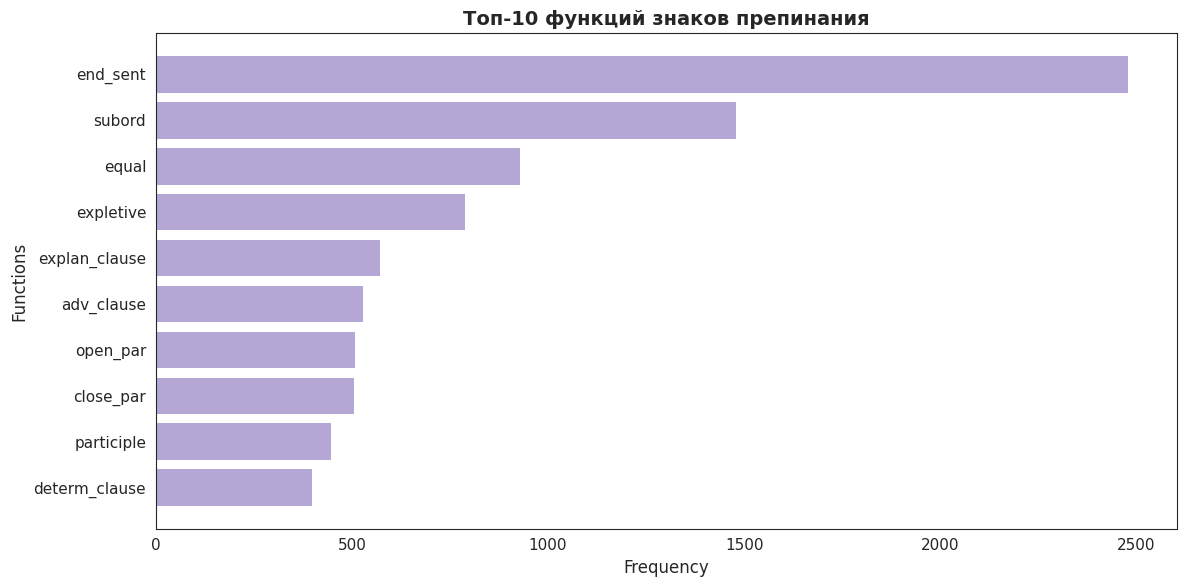

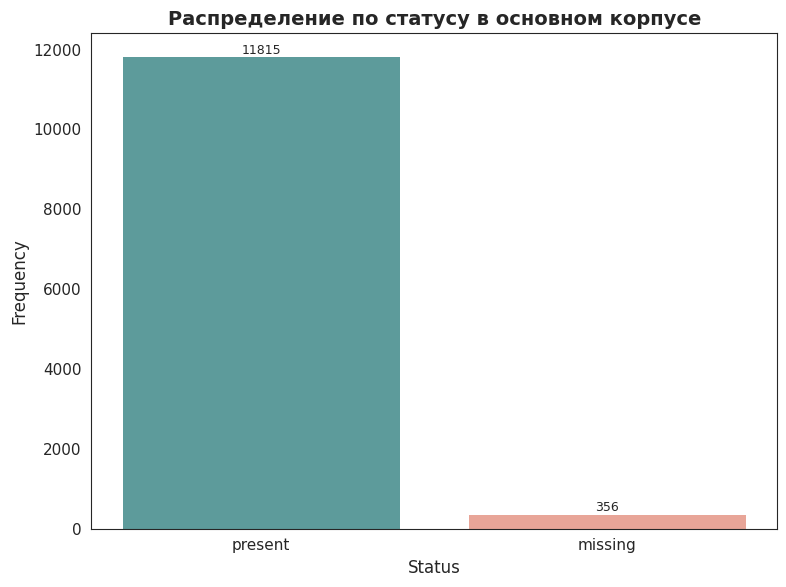


Tоп-15 знаков пунктуации


,Знак,Общее количество,Статус (present),Статус (missing)
0,comma,4712,4401,311
1,period,2655,2653,2
2,dash,1256,1233,23
3,lquot,854,848,6
4,rquot,853,847,6
5,rpar,494,493,1
6,lpar,473,472,1
7,colon,407,402,5
8,question,142,142,0
9,ellipsis,118,118,0



Анализ функций


,Знак,Всего функций,Уникальных функций,Топ-3 частотных,Топ-3 редких
0,period,2718,12,"end_sent (2281), abbrev_name (182), abbrev_wor...","join (1), no_union (1), explan (1)"
1,comma,7597,73,"subord (1470), equal (903), expletive (786)","explanation (1), adv_lause (1), apposotion (1)"
2,colon,598,20,"no_union (188), explan (186), direct_start (123)","subord (1), explan_clause (1), ganeral_equal (1)"
3,dash,1393,62,"word_parts (236), subj_pred (170), dialog_star...","indirect_end (1), explan_clause (1), follow (1)"
4,lpar,473,4,"open_par (454), remark (17), options (1)","options (1), specifier (1), remark (17)"
5,rpar,494,6,"close_par (456), remark (18), list (17)","open_par (1), options (1), adverbial (1)"
6,lquot,862,12,"expr_begin (306), quote_begin (213), term_begi...","qoute_begin (1), exp_begin (1), digit_name_beg..."
7,rquot,861,13,"expr_finish (304), quote_finish (212), term_fi...","figur_end (1), fterm_finish (1), qoute_finish (1)"
8,question,290,5,"question (141), end_sent (140), emotion (7)","parc (1), loud (1), emotion (7)"
9,semicolon,96,18,"equal (25), join (20), no_union (14)","determ_clause (1), united_clauses (1), follow (1)"



Распределение параметров

STATUS:


,Значение,Количество
0,present,11815
1,missing,356



NORMALITY:


,Значение,Количество
0,correct,9807
1,ind,106
2,facult,1718
3,typo,8
4,mistake,304
5,var,137
6,alt,88



SPACES:


,Значение,Количество
0,right,9083
1,zero,823
2,left,1435
3,bilateral,828


In [9]:
import xml.etree.ElementTree as ET
import os
from collections import defaultdict, Counter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

%matplotlib inline

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.15
plt.rcParams['grid.linestyle'] = '-'
plt.rcParams['axes.axisbelow'] = True

sns.set_style("white")

corpus_files = [
    "Лотман 50 тысяч золото.xml",
    "Дневник финальный.xml"
]
corpus_path = "."
output_file = "punctuation_stats.txt"
output_charts_dir = "punctuation_charts"
os.makedirs(output_charts_dir, exist_ok=True)

PUNCT_NORMALIZATION = {
    ',': 'comma', 'comma': 'comma',
    '.': 'period', 'period': 'period',
    '-': 'dash', '--': 'dash', '—': 'dash', 'dash': 'dash', 'double_hyphen': 'dash', 'hyphen': 'dash',
    '…': 'ellipsis', '...': 'ellipsis', 'ellipsis': 'ellipsis', 'horizontal_ellipsis': 'ellipsis',
    '?': 'question', 'quest': 'question',
    '!': 'exclamation', 'exclam': 'exclamation',
    '(': 'lpar', ')': 'rpar', 'lpar': 'lpar', 'rpar': 'rpar',
    '[': 'lsqbr', ']': 'rsqbr', 'lsqbr': 'lsqbr', 'rsqbr': 'rsqbr',
    '<': 'langlebr', '>': 'ranglebr', 'langle': 'langlebr', 'rangle': 'ranglebr',
    'left_angle': 'langlebr', 'right_angle': 'ranglebr',
    '«': 'lquot', '»': 'rquot', '„': 'lquot', '“': 'rquot', '"': 'quot',
    "'": 'apostrophe', '`': 'apostrophe', '’': 'apostrophe', '‘': 'apostrophe',
    '′': 'apostrophe', '‵': 'apostrophe', '″': 'apostrophe', '‴': 'apostrophe',
    'lquot': 'lquot', 'rquot': 'rquot', 'left_double_angle': 'lquot', 'right_double_angle': 'rquot',
    'lsquo': 'apostrophe', 'rsquo': 'apostrophe', 'ldquo': 'lquot', 'rdquo': 'rquot',
    'apostrophe': 'apostrophe', 'apostroph': 'apostrophe',
    '/': 'slash', '\\': 'backslash', 'slash': 'slash', 'backslash': 'backslash',
    ':': 'colon', 'colon': 'colon',
    ';': 'semicolon', 'semicolon': 'semicolon',
}

COLOR_PALETTE = {
    'correct': '#5D9B9B',
    'mistake': '#E8A598',
    'var': '#F4D03F',
    'facult': '#A8D5BA',
    'typo': '#B4A7D6',
    'alt': '#E8B4B8',
    'ind': '#C5B4A7',
}

BAR_COLOR = '#5D9B9B'
FUNCTIONS_COLOR = '#B4A7D6'


def normalize_punctuation(char):
    if char in PUNCT_NORMALIZATION:
        return PUNCT_NORMALIZATION[char]
    char_lower = char.lower()
    if char_lower in PUNCT_NORMALIZATION:
        return PUNCT_NORMALIZATION[char_lower]
    return char

def normalize_normality(value):
    if value is None:
        return None
    value = str(value).strip().lower()
    cyrillic_to_latin = {
        'с': 'c', 'о': 'o', 'р': 'p', 'е': 'e', 'у': 'y',
        'к': 'k', 'а': 'a', 'в': 'b', 'н': 'h', 'т': 't',
        'х': 'x', 'м': 'm', 'і': 'i', 'ї': 'i', 'є': 'e'
    }
    for cyr, lat in cyrillic_to_latin.items():
        value = value.replace(cyr, lat)
    if value == 'allt':
        return 'alt'
    if 'correct' in value:
        return 'correct'
    if 'mistake' in value:
        return 'mistake'
    return value

def extract_all_pc_elements(root):
    all_pc_elements = []
    for pc in root.iter('pc'):
        punct_char = pc.text if pc.text is not None else ""
        if punct_char.strip() == "":
            pc_type = pc.get('type')
            if pc_type:
                punct_char = pc_type
            else:
                continue
        punct_char = normalize_punctuation(punct_char)

        attrs = {}
        for attr_name in ['type', 'status', 'functions', 'normality', 'spaces', 'reliance', 'expression']:
            attr_val = pc.get(attr_name)
            if attr_val is not None:
                if attr_name == 'normality':
                    attr_val = normalize_normality(attr_val)
                attrs[attr_name] = attr_val

        parent = pc.getparent() if hasattr(pc, 'getparent') else None
        if parent is None:
            for elem in root.iter():
                if pc in list(elem):
                    parent = elem
                    break
        attrs['inside_span'] = 'True' if (parent is not None and parent.tag == 'span') else 'False'

        all_pc_elements.append({
            'знак': punct_char,
            'атрибуты': attrs
        })
    return all_pc_elements

def process_file(filepath):
    try:
        tree = ET.parse(filepath)
        root = tree.getroot()
    except Exception as e:
        print(f"Ошибка при чтении {filepath}: {e}")
        return None

    punct_counter = Counter()
    attr_stats = defaultdict(lambda: defaultdict(Counter))

    pc_elements = extract_all_pc_elements(root)
    print(f"  Найдено pc-элементов: {len(pc_elements)}")

    for item in pc_elements:
        punct_char = item['знак']
        punct_counter[punct_char] += 1

        for attr_name, attr_val in item['атрибуты'].items():
            attr_stats[punct_char][attr_name][attr_val] += 1

    return punct_counter, attr_stats

def plot_punctuation_distribution(punct_counter, title):
    sorted_items = sorted(punct_counter.items(), key=lambda x: x[1], reverse=True)
    signs = [item[0] for item in sorted_items]
    counts = [item[1] for item in sorted_items]

    plt.figure(figsize=(14, 7))
    bars = plt.bar(range(len(signs)), counts, color=BAR_COLOR, edgecolor='none')
    plt.xticks(range(len(signs)), signs, rotation=45, ha='right')
    plt.xlabel('Знаки препинания', fontsize=12)
    plt.ylabel('Частота', fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')

    for i, (bar, val) in enumerate(zip(bars, counts)):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(val), ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.show()
    return pd.DataFrame({'Знак': signs, 'Количество': counts})

def plot_normality_distribution(attr_stats, title):
    normality_data = []
    for sign, attrs in attr_stats.items():
        if 'normality' in attrs:
            for val, cnt in attrs['normality'].items():
                normality_data.append({'Знак': sign, 'Normality': val, 'Количество': cnt})

    if not normality_data:
        print("  Нет данных по нормативности")
        return None

    df_norm = pd.DataFrame(normality_data)
    pivot = df_norm.pivot_table(index='Знак', columns='Normality', values='Количество', fill_value=0)
    pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

    if len(pivot) > 15:
        pivot = pivot.head(15)

    available_colors = {k: v for k, v in COLOR_PALETTE.items() if k in pivot.columns}

    ax = pivot.plot(kind='bar', stacked=True, figsize=(14, 7),
                    color=available_colors, edgecolor='none')
    plt.xlabel('Punctuation marks', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.legend(title='Normality', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    return pivot

def plot_functions_distribution(attr_stats, title):
    func_counts = Counter()
    for attrs in attr_stats.values():
        if 'functions' in attrs:
            for val, cnt in attrs['functions'].items():
                for func in val.split(', '):
                    func_counts[func] += cnt

    if not func_counts:
        print("  Нет данных по функциям.")
        return

    top_functions = pd.Series(func_counts).sort_values(ascending=False).head(10)

    plt.figure(figsize=(12, 6))
    plt.barh(range(len(top_functions)), top_functions.values,
             color=FUNCTIONS_COLOR, edgecolor='none')
    plt.yticks(range(len(top_functions)), top_functions.index)
    plt.xlabel('Frequency', fontsize=12)
    plt.ylabel('Functions', fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

def plot_status_distribution(attr_stats, title):
    status_counts = Counter()
    for attrs in attr_stats.values():
        if 'status' in attrs:
            for val, cnt in attrs['status'].items():
                status_counts[val] += cnt

    if not status_counts:
        print("  No data for 'status' parameter.")
        return

    plt.figure(figsize=(8, 6))
    colors = [COLOR_PALETTE['correct'] if val == 'present' else COLOR_PALETTE['mistake'] for val in status_counts.keys()]
    bars = plt.bar(range(len(status_counts)), status_counts.values(), color=colors, edgecolor='none')
    plt.xticks(range(len(status_counts)), status_counts.keys())
    plt.xlabel('Status', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')

    for i, (bar, val) in enumerate(zip(bars, status_counts.values())):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(val), ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

def create_functions_table(attr_stats):
    results = []
    for sign, attrs in attr_stats.items():
        if 'functions' not in attrs:
            continue

        func_list = []
        for val, cnt in attrs['functions'].items():
            for func in val.split(', '):
                func_list.extend([func] * cnt)

        if not func_list:
            continue

        func_counter = Counter(func_list)
        total = len(func_list)
        unique = len(func_counter)

        top3 = func_counter.most_common(3)
        top3_str = ', '.join([f"{f} ({c})" for f, c in top3])

        bottom3 = sorted(func_counter.items(), key=lambda x: x[1])[:3]
        bottom3_str = ', '.join([f"{f} ({c})" for f, c in bottom3])

        results.append({
            'Знак': sign,
            'Всего функций': total,
            'Уникальных функций': unique,
            'Топ-3 частотных': top3_str,
            'Топ-3 редких': bottom3_str
        })

    return pd.DataFrame(results) if results else None

def create_summary_table(punct_counter, attr_stats):
    summary_data = []
    for sign, total in sorted(punct_counter.items(), key=lambda x: x[1], reverse=True)[:15]:
        attrs = attr_stats.get(sign, {})
        present = attrs.get('status', {}).get('present', 0)
        missing = attrs.get('status', {}).get('missing', 0)
        summary_data.append({
            'Знак': sign,
            'Общее количество': total,
            'Статус (present)': present,
            'Статус (missing)': missing,
        })
    return pd.DataFrame(summary_data)

def main():
    all_punct_counters = []
    all_attr_stats = []
    aggregated_punct_counter = Counter()
    aggregated_attr_stats = defaultdict(lambda: defaultdict(Counter))

    for filename in corpus_files:
        full_path = os.path.join(corpus_path, filename)
        if not os.path.exists(full_path):
            print(f"File not found: {full_path}")
            continue

        punct_counter, attr_stats = process_file(full_path)
        if punct_counter is not None:
            all_punct_counters.append((filename, punct_counter))
            all_attr_stats.append((filename, attr_stats))

            for sign, count in punct_counter.items():
                aggregated_punct_counter[sign] += count
            for sign, attrs in attr_stats.items():
                for attr_name, counter in attrs.items():
                    for val, cnt in counter.items():
                        aggregated_attr_stats[sign][attr_name][val] += cnt

    total_punct = sum(aggregated_punct_counter.values())

    print(f"Всего знаков препинания в корпусе: {total_punct}")


    plot_punctuation_distribution(aggregated_punct_counter, "Распределение знаков препинания в основном корпусе")

    plot_normality_distribution(aggregated_attr_stats, "Распределение по нормативности в основном корпусе")

    plot_functions_distribution(aggregated_attr_stats, "Топ-10 функций знаков препинания")

    plot_status_distribution(aggregated_attr_stats, "Распределение по статусу в основном корпусе")



    print("\nTоп-15 знаков пунктуации")
    summary_df = create_summary_table(aggregated_punct_counter, aggregated_attr_stats)
    display(summary_df)

    print("\nАнализ функций")
    functions_df = create_functions_table(aggregated_attr_stats)
    if functions_df is not None:
        display(functions_df)

    print("\nРаспределение параметров")
    for param_name in ['status', 'normality', 'spaces']:
        param_counts = Counter()
        for attrs in aggregated_attr_stats.values():
            if param_name in attrs:
                for val, cnt in attrs[param_name].items():
                    param_counts[val] += cnt
        if param_counts:
            param_df = pd.DataFrame([{'Значение': k, 'Количество': v} for k, v in param_counts.items()])
            print(f"\n{param_name.upper()}:")
            display(param_df)

if __name__ == "__main__":
    main()

  Найдено pc-элементов: 10922
  Найдено pc-элементов: 1249
Всего рс-элементов: 12171


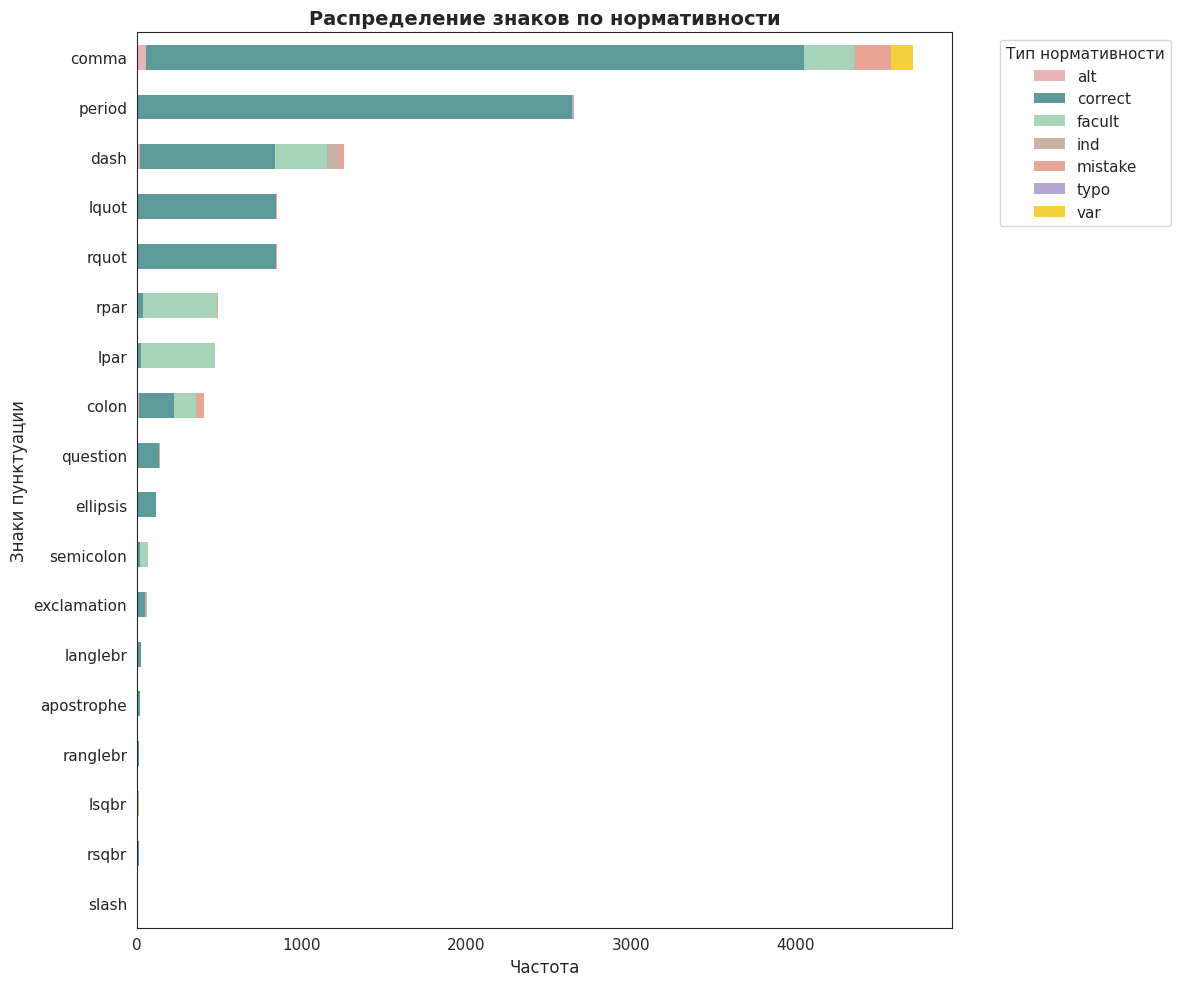


Всего ненормативных знаков: 2361
Нормативных знаков (correct): 9807


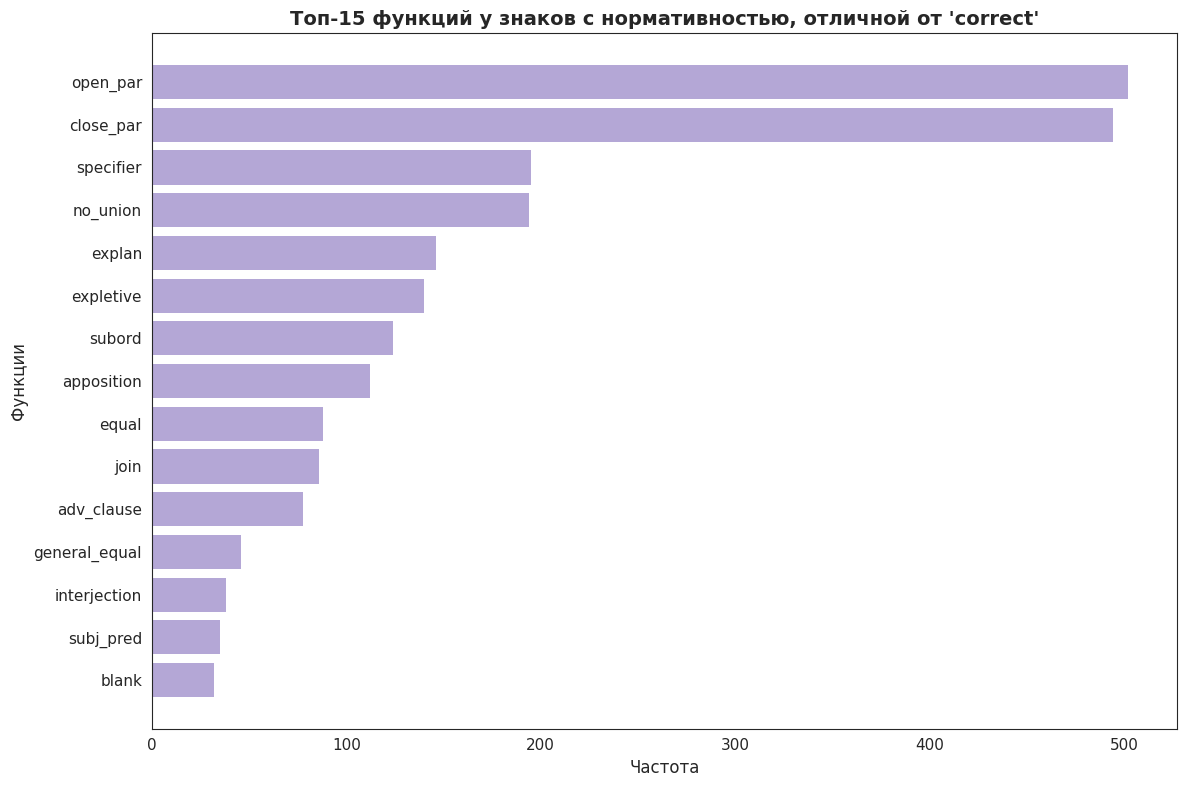

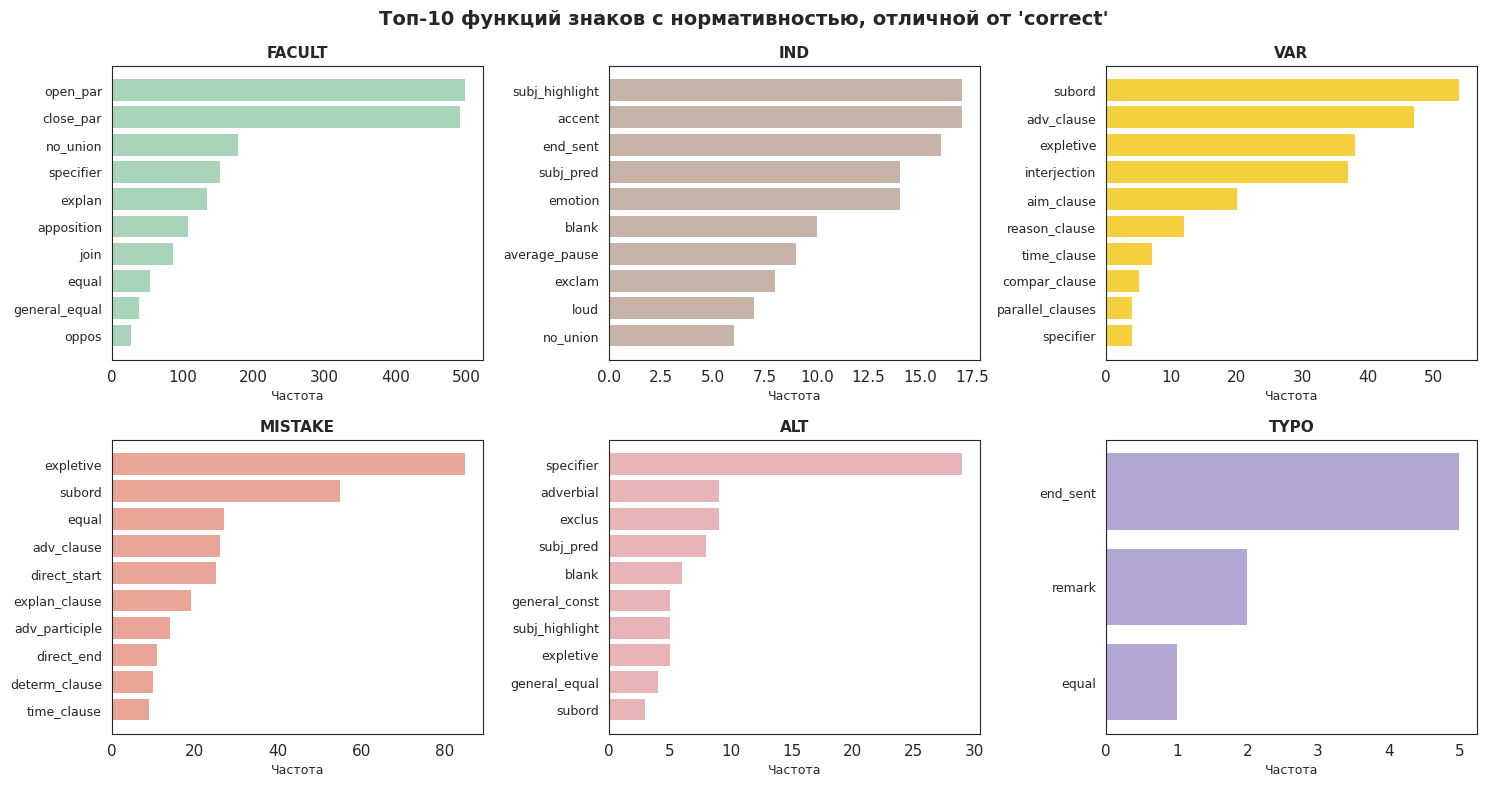

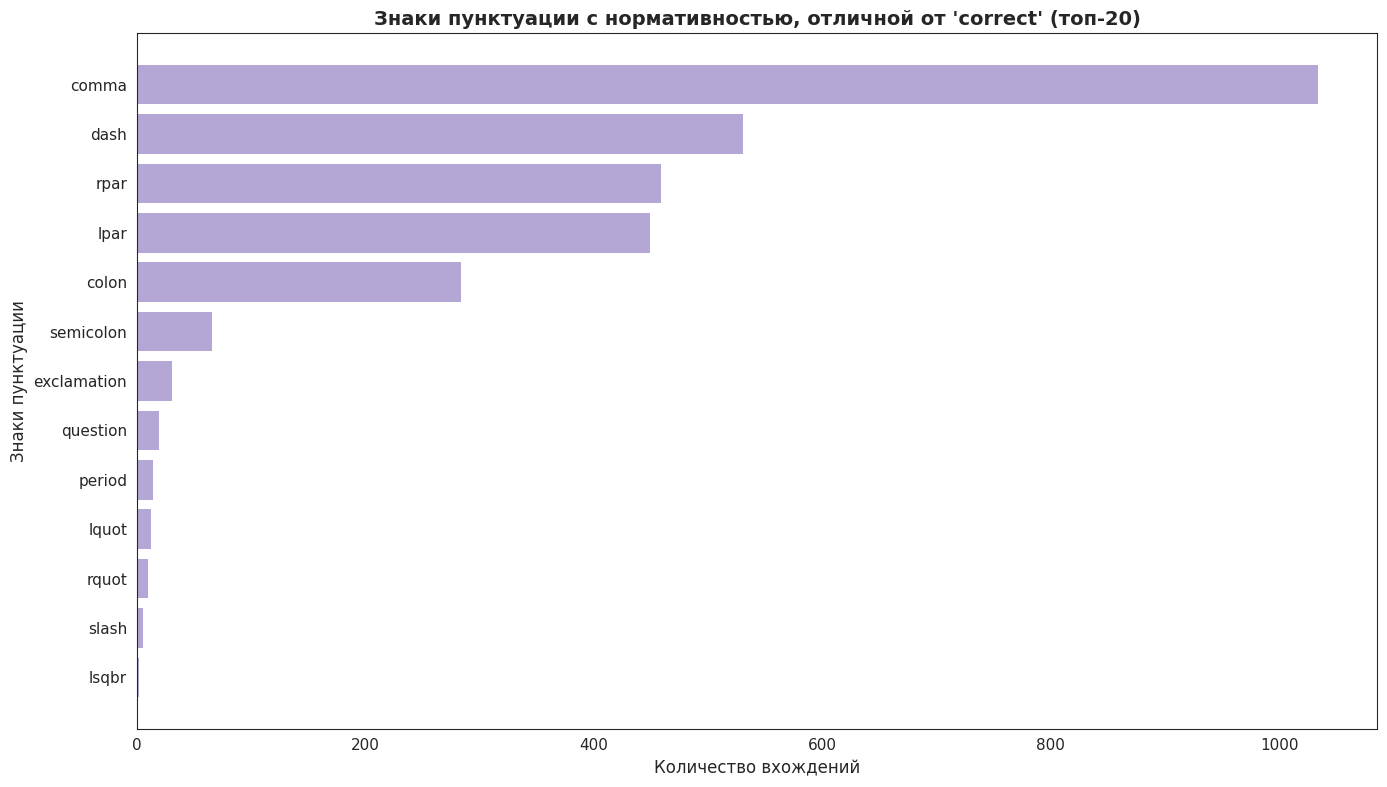


Детальный анализ ненормативных знаков


,Знак,Всего non-correct,Топ-3 функции,Уникальных функций
2,comma,1034,"specifier (139), expletive (137), subord (120)",48
3,dash,531,"apposition (83), specifier (53), no_union (52)",47
1,rpar,459,"close_par (446), list (8), remark (2)",6
0,lpar,449,"open_par (447), options (1), specifier (1)",3
4,colon,284,"no_union (92), explan (91), general_equal (35)",16
5,semicolon,66,"equal (21), join (14), no_union (9)",14
11,exclamation,31,"end_sent (9), exclam (8), emotion (8)",4
12,question,19,"end_sent (6), question (6), emotion (6)",4
8,period,14,"end_sent (7), abbrev_name (2), ellipsis (2)",6
6,lquot,12,"expr_begin (7), quote_begin (2), figur_begin (2)",4



Топ-20 функций знаков с нормативностью, отличной от 'correct'


,Функция,Частота
0,open_par,502
1,close_par,494
2,specifier,195
3,no_union,194
4,explan,146
5,expletive,140
6,subord,124
7,apposition,112
8,equal,88
9,join,86


In [10]:
USE_HORIZONTAL_NORMALITY = True
MAX_SIGNS_TO_SHOW = 20


NORMALITY_TAGS = {
    'correct': 'correct',
    'mistake': 'mistake',
    'var': 'var',
    'facult': 'facult',
    'typo': 'typo',
    'alt': 'alt',
    'ind': 'ind',
}

NON_CORRECT_COLORS = {
    'mistake': COLOR_PALETTE['mistake'],
    'var': COLOR_PALETTE['var'],
    'facult': COLOR_PALETTE['facult'],
    'typo': COLOR_PALETTE['typo'],
    'alt': COLOR_PALETTE['alt'],
    'ind': COLOR_PALETTE['ind'],
}

MAIN_COLOR = '#B4A7D6'  # лавандовый

def normalize_punctuation(char):
    PUNCT_NORMALIZATION = {
        ',': 'comma', 'comma': 'comma',
        '.': 'period', 'period': 'period',
        '-': 'dash', '--': 'dash', '—': 'dash', 'dash': 'dash', 'double_hyphen': 'dash', 'hyphen': 'dash',
        '…': 'ellipsis', '...': 'ellipsis', 'ellipsis': 'ellipsis', 'horizontal_ellipsis': 'ellipsis',
        '?': 'question', 'quest': 'question',
        '!': 'exclamation', 'exclam': 'exclamation',
        '(': 'lpar', ')': 'rpar', 'lpar': 'lpar', 'rpar': 'rpar',
        '[': 'lsqbr', ']': 'rsqbr', 'lsqbr': 'lsqbr', 'rsqbr': 'rsqbr',
        '<': 'langlebr', '>': 'ranglebr', 'langle': 'langlebr', 'rangle': 'ranglebr',
        '«': 'lquot', '»': 'rquot', '„': 'lquot', '“': 'rquot', '"': 'quot',
        "'": 'apostrophe', '`': 'apostrophe', '’': 'apostrophe', '‘': 'apostrophe',
        '′': 'apostrophe', '‵': 'apostrophe', '″': 'apostrophe', '‴': 'apostrophe',
        'lquot': 'lquot', 'rquot': 'rquot', 'left_double_angle': 'lquot', 'right_double_angle': 'rquot',
        'lsquo': 'apostrophe', 'rsquo': 'apostrophe', 'ldquo': 'lquot', 'rdquo': 'rquot',
        'apostrophe': 'apostrophe', 'apostroph': 'apostrophe',
        '/': 'slash', '\\': 'backslash', 'slash': 'slash', 'backslash': 'backslash',
        ':': 'colon', 'colon': 'colon',
        ';': 'semicolon', 'semicolon': 'semicolon',
    }
    if char in PUNCT_NORMALIZATION:
        return PUNCT_NORMALIZATION[char]
    char_lower = char.lower()
    if char_lower in PUNCT_NORMALIZATION:
        return PUNCT_NORMALIZATION[char_lower]
    return char

def normalize_normality(value):
    if value is None:
        return None
    value = str(value).strip().lower()
    cyrillic_to_latin = {
        'с': 'c', 'о': 'o', 'р': 'p', 'е': 'e', 'у': 'y',
        'к': 'k', 'а': 'a', 'в': 'b', 'н': 'h', 'т': 't',
        'х': 'x', 'м': 'm', 'і': 'i', 'ї': 'i', 'є': 'e'
    }
    for cyr, lat in cyrillic_to_latin.items():
        value = value.replace(cyr, lat)
    if value == 'allt':
        return 'alt'
    if 'correct' in value:
        return 'correct'
    if 'mistake' in value:
        return 'mistake'
    return value

def extract_all_pc_elements(root):
    all_pc_elements = []
    for pc in root.iter('pc'):
        punct_char = pc.text if pc.text is not None else ""
        if punct_char.strip() == "":
            pc_type = pc.get('type')
            if pc_type:
                punct_char = pc_type
            else:
                continue
        punct_char = normalize_punctuation(punct_char)

        attrs = {}
        for attr_name in ['type', 'status', 'functions', 'normality', 'spaces', 'reliance', 'expression']:
            attr_val = pc.get(attr_name)
            if attr_val is not None:
                if attr_name == 'normality':
                    attr_val = normalize_normality(attr_val)
                attrs[attr_name] = attr_val

        all_pc_elements.append({
            'знак': punct_char,
            'атрибуты': attrs
        })
    return all_pc_elements

def process_file(filepath):
    try:
        tree = ET.parse(filepath)
        root = tree.getroot()
    except Exception as e:
        print(f"Ошибка при чтении {filepath}: {e}")
        return None

    pc_elements = extract_all_pc_elements(root)
    print(f"  Найдено pc-элементов: {len(pc_elements)}")
    return pc_elements

def get_aggregated_attr_stats(pc_elements):
    aggregated_attr_stats = defaultdict(lambda: defaultdict(Counter))

    for item in pc_elements:
        punct_char = item['знак']
        for attr_name, attr_val in item['атрибуты'].items():
            aggregated_attr_stats[punct_char][attr_name][attr_val] += 1

    return aggregated_attr_stats

def plot_normality_distribution(attr_stats, title):

    normality_data = []
    for sign, attrs in attr_stats.items():
        if 'normality' in attrs:
            for val, cnt in attrs['normality'].items():
                rus_val = NORMALITY_TAGS.get(val, val)
                normality_data.append({'Знак': sign, 'Normality': rus_val, 'Количество': cnt})

    if not normality_data:
        print("  Нет данных для параметра 'normality'.")
        return None

    df_norm = pd.DataFrame(normality_data)
    pivot = df_norm.pivot_table(index='Знак', columns='Normality', values='Количество', fill_value=0)

    pivot['total'] = pivot.sum(axis=1)
    pivot = pivot.sort_values('total', ascending=True)
    pivot = pivot.drop('total', axis=1)

    if len(pivot) > MAX_SIGNS_TO_SHOW:
        pivot = pivot.tail(MAX_SIGNS_TO_SHOW)

    available_colors = {}
    for eng, rus in NORMALITY_TAGS.items():
        if rus in pivot.columns:
            available_colors[rus] = COLOR_PALETTE.get(eng, '#95a5a6')

    if USE_HORIZONTAL_NORMALITY:
        ax = pivot.plot(kind='barh', stacked=True, figsize=(12, 10),
                        color=available_colors, edgecolor='none')
        plt.xlabel('Частота', fontsize=12)
        plt.ylabel('Знаки пунктуации', fontsize=12)
    else:
        ax = pivot.plot(kind='bar', stacked=True, figsize=(14, 7),
                        color=available_colors, edgecolor='none')
        plt.xlabel('Знаки пунктуации', fontsize=12)
        plt.ylabel('Частота', fontsize=12)
        plt.xticks(rotation=45, ha='right')

    plt.title(title, fontsize=14, fontweight='bold')
    plt.legend(title='Тип нормативности', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    return pivot

def plot_top_functions_non_correct(data, top_n=15):
    all_functions = data['all_functions_non_correct']
    top_functions = all_functions.most_common(top_n)

    plt.figure(figsize=(12, 8))
    func_names = [f[0] for f in top_functions[::-1]]
    func_counts = [f[1] for f in top_functions[::-1]]

    plt.barh(range(len(func_names)), func_counts, color=MAIN_COLOR, edgecolor='none')
    plt.yticks(range(len(func_names)), func_names)
    plt.xlabel('Частота', fontsize=12)
    plt.ylabel('Функции', fontsize=12)
    plt.title(f"Топ-{top_n} функций у знаков с нормативностью, отличной от 'correct'", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

def plot_functions_by_normality_type(data, top_n=10):
    functions_by_normality = data['functions_by_normality']

    non_correct_types = [t for t in functions_by_normality.keys() if t != 'correct']

    if not non_correct_types:
        print("Не найдено типов ненормативной разметки")
        return

    type_labels = [NORMALITY_TAGS.get(t, t) for t in non_correct_types]

    cols = min(3, len(non_correct_types))
    rows = (len(non_correct_types) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))

    if rows == 1 and cols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for idx, norm_type in enumerate(non_correct_types):
        ax = axes[idx]
        func_counts = functions_by_normality[norm_type]
        top_funcs = func_counts.most_common(top_n)

        if top_funcs:
            func_names = [f[0] for f in top_funcs[::-1]]
            func_vals = [f[1] for f in top_funcs[::-1]]

            ax.barh(range(len(func_names)), func_vals,
                    color=NON_CORRECT_COLORS.get(norm_type, '#95a5a6'),
                    edgecolor='none')
            ax.set_yticks(range(len(func_names)))
            ax.set_yticklabels(func_names, fontsize=9)
            ax.set_xlabel('Частота', fontsize=9)
            ax.set_title(type_labels[idx].upper(), fontsize=11, fontweight='bold')
        else:
            ax.text(0.5, 0.5, f'Нет данных для {type_labels[idx]}',
                    ha='center', va='center', transform=ax.transAxes)
            ax.set_title(type_labels[idx].upper(), fontsize=11, fontweight='bold')

    for idx in range(len(non_correct_types), len(axes)):
        axes[idx].set_visible(False)

    plt.suptitle("Топ-10 функций знаков с нормативностью, отличной от 'correct'", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

def plot_signs_with_most_non_correct(data, top_n=20):
    sign_functions = data['sign_functions_non_correct']

    sign_non_correct_counts = {sign: sum(counter.values()) for sign, counter in sign_functions.items()}
    top_signs = sorted(sign_non_correct_counts.items(), key=lambda x: x[1], reverse=True)[:top_n]

    plt.figure(figsize=(14, 8))
    signs = [s[0] for s in top_signs[::-1]]
    counts = [s[1] for s in top_signs[::-1]]

    plt.barh(range(len(signs)), counts, color=MAIN_COLOR, edgecolor='none')
    plt.yticks(range(len(signs)), signs)
    plt.xlabel('Количество вхождений', fontsize=12)
    plt.ylabel('Знаки пунктуации', fontsize=12)
    plt.title(f"Знаки пунктуации с нормативностью, отличной от 'correct' (топ-{top_n})",
              fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return top_signs

def analyze_non_correct_functions(pc_elements):
    normality_types = Counter()
    functions_by_normality = defaultdict(Counter)
    sign_functions_non_correct = defaultdict(Counter)
    all_functions_non_correct = Counter()

    for item in pc_elements:
        attrs = item['атрибуты']
        if 'normality' not in attrs:
            continue

        normality = attrs['normality']
        normality_types[normality] += 1

        if 'functions' in attrs:
            functions = attrs['functions'].split(', ')

            if normality != 'correct':
                for func in functions:
                    functions_by_normality[normality][func] += 1
                    all_functions_non_correct[func] += 1
                    sign_functions_non_correct[item['знак']][func] += 1

    return {
        'normality_types': normality_types,
        'functions_by_normality': functions_by_normality,
        'all_functions_non_correct': all_functions_non_correct,
        'sign_functions_non_correct': sign_functions_non_correct
    }

def create_detailed_table(data):
    sign_functions = data['sign_functions_non_correct']

    results = []
    for sign, func_counter in sign_functions.items():
        total = sum(func_counter.values())
        top3 = func_counter.most_common(3)
        top3_str = ', '.join([f"{f} ({c})" for f, c in top3])

        results.append({
            'Знак': sign,
            'Всего non-correct': total,
            'Топ-3 функции': top3_str,
            'Уникальных функций': len(func_counter)
        })

    df = pd.DataFrame(results)
    df = df.sort_values('Всего non-correct', ascending=False)
    return df

def main():
    all_pc_elements = []

    for filename in corpus_files:
        full_path = os.path.join(corpus_path, filename)
        if not os.path.exists(full_path):
            print(f"Файл не найден: {full_path}")
            continue

        pc_elements = process_file(full_path)
        if pc_elements:
            all_pc_elements.extend(pc_elements)

    if not all_pc_elements:
        print("Данные не найдены")
        return

    print(f"Всего рс-элементов: {len(all_pc_elements)}")

    aggregated_attr_stats = get_aggregated_attr_stats(all_pc_elements)

    plot_normality_distribution(aggregated_attr_stats, "Распределение знаков по нормативности")

    data = analyze_non_correct_functions(all_pc_elements)

    total_non_correct = sum(data['normality_types'].values()) - data['normality_types'].get('correct', 0)
    print(f"\nВсего ненормативных знаков: {total_non_correct}")
    print(f"Нормативных знаков (correct): {data['normality_types'].get('correct', 0)}")

    plot_top_functions_non_correct(data, top_n=15)

    plot_functions_by_normality_type(data, top_n=10)

    plot_signs_with_most_non_correct(data, top_n=20)


    print("\nДетальный анализ ненормативных знаков")
    detailed_df = create_detailed_table(data)
    display(detailed_df.head(30))

    print("\nТоп-20 функций знаков с нормативностью, отличной от 'correct'")
    all_funcs = data['all_functions_non_correct']
    func_df = pd.DataFrame(all_funcs.most_common(20), columns=['Функция', 'Частота'])
    display(func_df)

if __name__ == "__main__":
    main()


Обработка Лотман 50 тысяч золото.xml...
  Найдено отсутствующих знаков (внутри span): 145

Обработка Дневник финальный.xml...
  Найдено отсутствующих знаков (внутри span): 213

Всего отсутствующих знаков: 358

Самые частотные отсутствующие знаки:


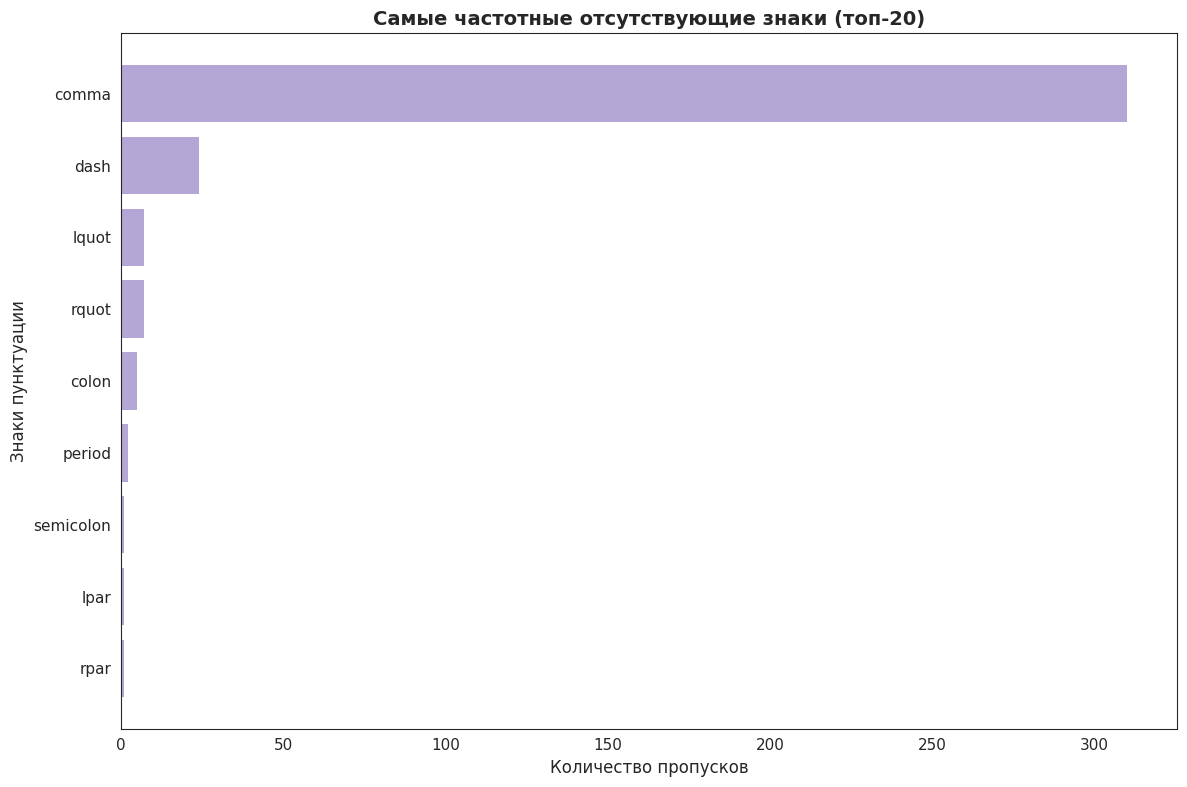


Функции отсутствующих знаков:


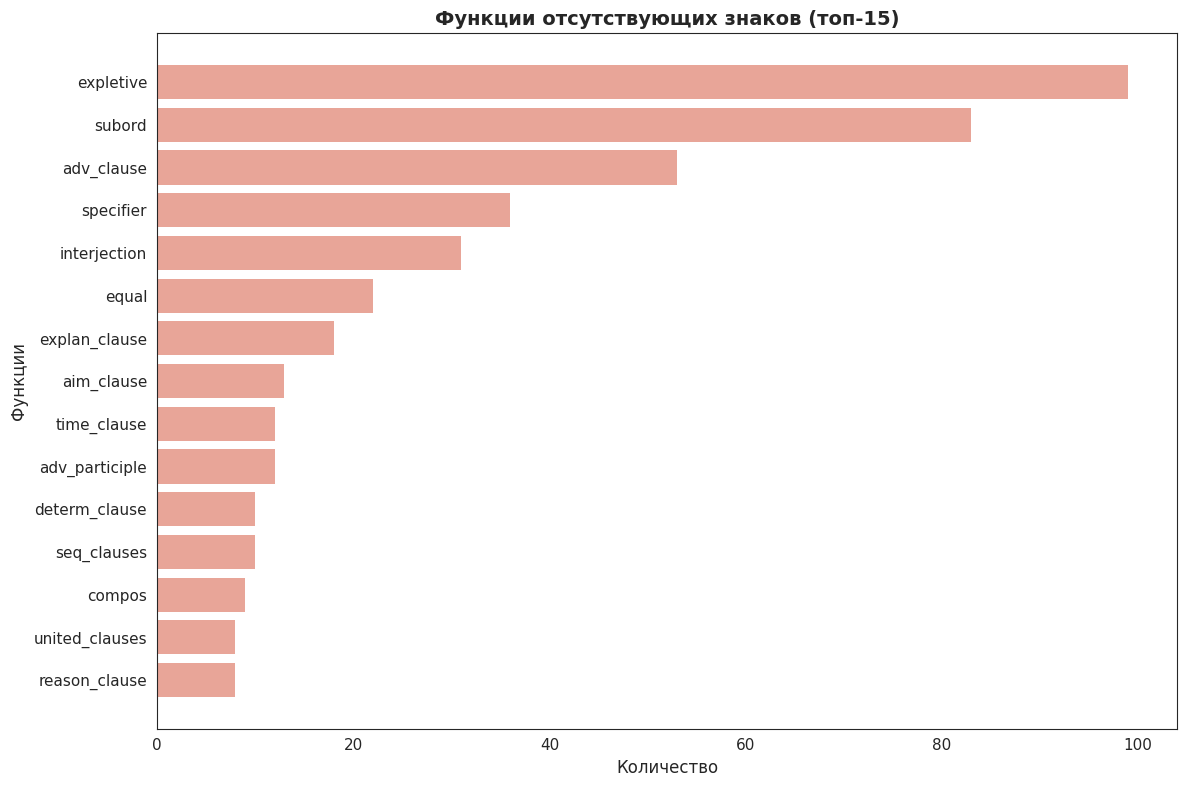


Нормативность по знакам:


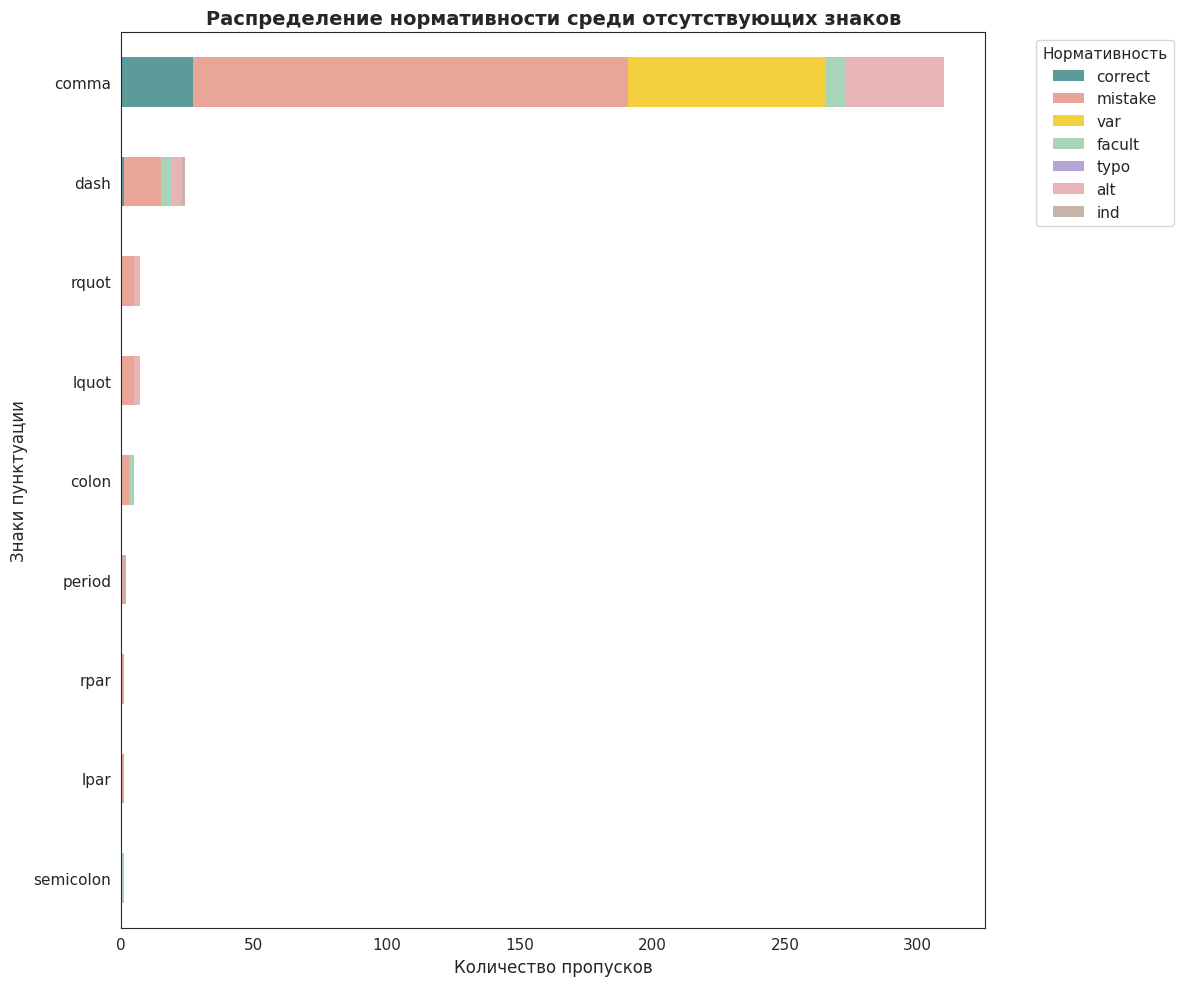


Функции по типам нормативности:


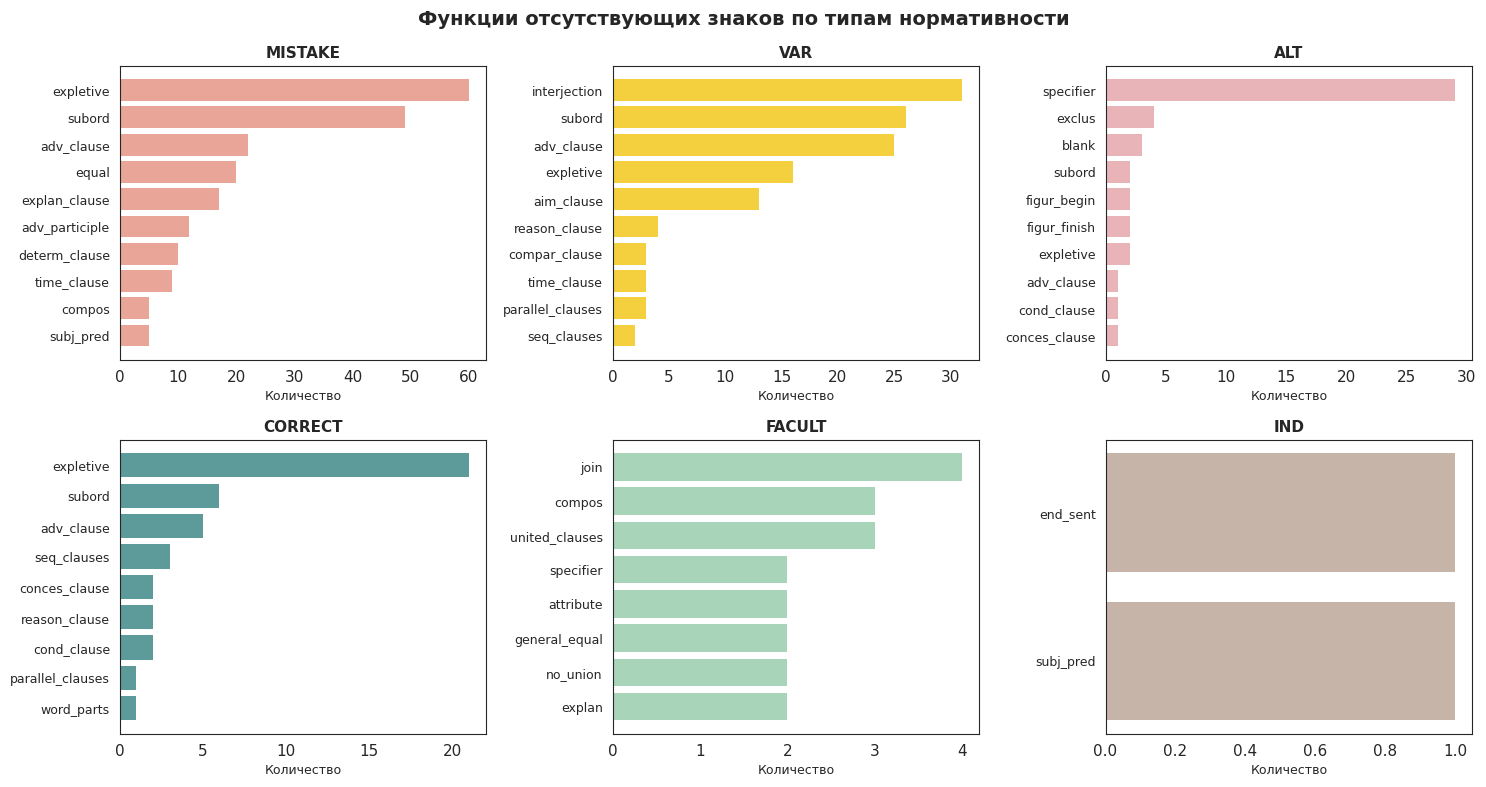


Нормативность отсутствующих знаков по знакам


,Знак,Всего пропусков,correct,mistake,var,facult,typo,alt,ind
0,comma,310,27,164,74,8,0,37,0
3,dash,24,1,14,0,4,0,4,1
1,lquot,7,0,5,0,0,0,2,0
2,rquot,7,0,5,0,0,0,2,0
5,colon,5,0,3,0,2,0,0,0
4,period,2,0,1,0,0,0,0,1
6,semicolon,1,0,0,0,1,0,0,0
7,lpar,1,0,1,0,0,0,0,0
8,rpar,1,0,1,0,0,0,0,0



Функции отсутствующих знаков по знакам


,Знак,Всего функций,Уникальных функций,Топ-3 функции
0,comma,484,36,"expletive (99), subord (83), adv_clause (53)"
3,dash,26,12,"subj_pred (6), word_parts (5), general_equal (3)"
1,lquot,7,3,"expr_begin (4), figur_begin (2), quote_begin (1)"
2,rquot,7,3,"expr_finish (4), figur_finish (2), quote_finis..."
5,colon,6,5,"general_const (2), general_equal (1), indirect..."
4,period,2,2,"end_sent (1), abbrev_name (1)"
6,semicolon,1,1,join (1)
7,lpar,1,1,open_par (1)
8,rpar,1,1,close_par (1)



Таблица сохранена в файл: missing_signs_analysis.csv

Распределение по нормативности:
  mistake: 194 (54.2%)
  var: 74 (20.7%)
  alt: 45 (12.6%)
  correct: 28 (7.8%)
  facult: 15 (4.2%)
  ind: 2 (0.6%)

Топ-5 отсутствующих знаков:
  comma: 310
  dash: 24
  lquot: 7
  rquot: 7
  colon: 5

Топ-5 функций у отсутствующих знаков:
  expletive: 99
  subord: 83
  adv_clause: 53
  specifier: 36
  interjection: 31


In [11]:
MAX_SIGNS_TO_SHOW = 20

def normalize_normality(value):
    """Нормализует значение параметра normality."""
    if value is None:
        return None
    value = str(value).strip().lower()
    cyrillic_to_latin = {
        'с': 'c', 'о': 'o', 'р': 'p', 'е': 'e', 'у': 'y',
        'к': 'k', 'а': 'a', 'в': 'b', 'н': 'h', 'т': 't',
        'х': 'x', 'м': 'm', 'і': 'i', 'ї': 'i', 'є': 'e'
    }
    for cyr, lat in cyrillic_to_latin.items():
        value = value.replace(cyr, lat)
    if value == 'allt':
        return 'alt'
    if 'correct' in value:
        return 'correct'
    if 'mistake' in value:
        return 'mistake'
    return value

def extract_missing_pc_elements(root):
    missing_elements = []

    for span in root.iter('span'):
        for pc in span.iter('pc'):
            punct_char = pc.text if pc.text is not None else ""
            if punct_char.strip() == "":
                pc_type = pc.get('type')
                if pc_type:
                    punct_char = pc_type
                else:
                    continue
            punct_char = normalize_punctuation(punct_char)

            attrs = {}
            for attr_name in ['type', 'status', 'functions', 'normality', 'spaces', 'reliance']:
                attr_val = pc.get(attr_name)
                if attr_val is not None:
                    if attr_name == 'normality':
                        attr_val = normalize_normality(attr_val)
                    attrs[attr_name] = attr_val

            missing_elements.append({
                'знак': punct_char,
                'атрибуты': attrs
            })

    return missing_elements

def process_file(filepath):
    try:
        tree = ET.parse(filepath)
        root = tree.getroot()
    except Exception as e:
        print(f"Ошибка при чтении {filepath}: {e}")
        return None

    missing_elements = extract_missing_pc_elements(root)
    print(f"  Найдено отсутствующих знаков (внутри span): {len(missing_elements)}")
    return missing_elements

def analyze_missing_signs(missing_elements):
    sign_counter = Counter()
    normality_counter = Counter()
    function_counter = Counter()
    sign_normality = defaultdict(Counter)
    sign_functions = defaultdict(Counter)
    normality_functions = defaultdict(Counter)

    for item in missing_elements:
        sign = item['знак']
        attrs = item['атрибуты']

        sign_counter[sign] += 1

        normality = attrs.get('normality', 'unknown')
        normality_counter[normality] += 1
        sign_normality[sign][normality] += 1

        functions = attrs.get('functions', '')
        if functions:
            for func in functions.split(', '):
                if func:
                    function_counter[func] += 1
                    sign_functions[sign][func] += 1
                    normality_functions[normality][func] += 1

    return {
        'sign_counter': sign_counter,
        'normality_counter': normality_counter,
        'function_counter': function_counter,
        'sign_normality': sign_normality,
        'sign_functions': sign_functions,
        'normality_functions': normality_functions,
        'total_missing': len(missing_elements)
    }

def plot_missing_signs_distribution(data, top_n=20):
    sign_counter = data['sign_counter']
    top_signs = sign_counter.most_common(top_n)

    plt.figure(figsize=(12, 8))
    signs = [s[0] for s in top_signs[::-1]]
    counts = [s[1] for s in top_signs[::-1]]

    plt.barh(range(len(signs)), counts, color=MAIN_COLOR, edgecolor='none')
    plt.yticks(range(len(signs)), signs)
    plt.xlabel('Количество пропусков', fontsize=12)
    plt.ylabel('Знаки пунктуации', fontsize=12)
    plt.title(f'Самые частотные отсутствующие знаки (топ-{top_n})', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

def plot_missing_functions_distribution(data, top_n=15):
    function_counter = data['function_counter']
    top_functions = function_counter.most_common(top_n)

    plt.figure(figsize=(12, 8))
    func_names = [f[0] for f in top_functions[::-1]]
    func_counts = [f[1] for f in top_functions[::-1]]

    plt.barh(range(len(func_names)), func_counts, color='#E8A598', edgecolor='none')
    plt.yticks(range(len(func_names)), func_names)
    plt.xlabel('Количество', fontsize=12)
    plt.ylabel('Функции', fontsize=12)
    plt.title(f'Функции отсутствующих знаков (топ-{top_n})', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

def plot_missing_normality_by_sign(data, top_n=20):
    sign_normality = data['sign_normality']

    sign_counts = {sign: sum(counter.values()) for sign, counter in sign_normality.items()}
    top_signs = sorted(sign_counts.items(), key=lambda x: x[1], reverse=True)[:top_n]

    results = []
    for sign, total in top_signs:
        row = {'знак': sign}
        for norm in ['correct', 'mistake', 'var', 'facult', 'typo', 'alt', 'ind']:
            row[norm] = sign_normality[sign].get(norm, 0)
        results.append(row)

    df = pd.DataFrame(results)
    df = df.set_index('знак')

    df['total'] = df.sum(axis=1)
    df = df.sort_values('total', ascending=True)
    df = df.drop('total', axis=1)
    df = df.tail(top_n)

    colors = {norm: COLOR_PALETTE[norm] for norm in ['correct', 'mistake', 'var', 'facult', 'typo', 'alt', 'ind']
              if norm in df.columns}

    ax = df.plot(kind='barh', stacked=True, figsize=(12, 10),
                 color=colors, edgecolor='none')
    plt.xlabel('Количество пропусков', fontsize=12)
    plt.ylabel('Знаки пунктуации', fontsize=12)
    plt.title('Распределение нормативности среди отсутствующих знаков', fontsize=14, fontweight='bold')
    plt.legend(title='Нормативность', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

def plot_missing_functions_by_normality(data, top_n=10):
    normality_functions = data['normality_functions']

    norm_types = [n for n in normality_functions.keys() if n != 'unknown']

    if not norm_types:
        print("Нет данных для анализа функций по типам нормативности")
        return

    norm_types = sorted(norm_types, key=lambda x: sum(normality_functions[x].values()), reverse=True)

    cols = min(3, len(norm_types))
    rows = (len(norm_types) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))

    if rows == 1 and cols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for idx, norm_type in enumerate(norm_types):
        ax = axes[idx]
        func_counts = normality_functions[norm_type]
        top_funcs = func_counts.most_common(top_n)

        if top_funcs:
            func_names = [f[0] for f in top_funcs[::-1]]
            func_vals = [f[1] for f in top_funcs[::-1]]

            ax.barh(range(len(func_names)), func_vals,
                    color=COLOR_PALETTE.get(norm_type, '#95a5a6'),
                    edgecolor='none')
            ax.set_yticks(range(len(func_names)))
            ax.set_yticklabels(func_names, fontsize=9)
            ax.set_xlabel('Количество', fontsize=9)
            ax.set_title(f'{norm_type.upper()}', fontsize=11, fontweight='bold')
        else:
            ax.text(0.5, 0.5, f'Нет данных для {norm_type}',
                    ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{norm_type.upper()}', fontsize=11, fontweight='bold')

    for idx in range(len(norm_types), len(axes)):
        axes[idx].set_visible(False)

    plt.suptitle('Функции отсутствующих знаков по типам нормативности', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

def create_summary_table(data):
    sign_normality = data['sign_normality']

    results = []
    for sign, counter in sign_normality.items():
        total = sum(counter.values())
        results.append({
            'Знак': sign,
            'Всего пропусков': total,
            'correct': counter.get('correct', 0),
            'mistake': counter.get('mistake', 0),
            'var': counter.get('var', 0),
            'facult': counter.get('facult', 0),
            'typo': counter.get('typo', 0),
            'alt': counter.get('alt', 0),
            'ind': counter.get('ind', 0)
        })

    df = pd.DataFrame(results)
    df = df.sort_values('Всего пропусков', ascending=False)
    return df

def create_functions_table(data):
    sign_functions = data['sign_functions']

    results = []
    for sign, func_counter in sign_functions.items():
        total = sum(func_counter.values())
        top3 = func_counter.most_common(3)
        top3_str = ', '.join([f"{f} ({c})" for f, c in top3])

        results.append({
            'Знак': sign,
            'Всего функций': total,
            'Уникальных функций': len(func_counter),
            'Топ-3 функции': top3_str
        })

    df = pd.DataFrame(results)
    df = df.sort_values('Всего функций', ascending=False)
    return df

def main():
    all_missing_elements = []

    for filename in corpus_files:
        full_path = os.path.join(corpus_path, filename)
        if not os.path.exists(full_path):
            print(f"Файл не найден: {full_path}")
            continue

        print(f"\nОбработка {filename}...")
        missing_elements = process_file(full_path)
        if missing_elements:
            all_missing_elements.extend(missing_elements)

    if not all_missing_elements:
        print("\nОтсутствующие знаки (внутри span) не найдены.")
        return

    print(f"\nВсего отсутствующих знаков: {len(all_missing_elements)}")

    data = analyze_missing_signs(all_missing_elements)

    print("\nСамые частотные отсутствующие знаки:")
    plot_missing_signs_distribution(data, top_n=MAX_SIGNS_TO_SHOW)

    print("\nФункции отсутствующих знаков:")
    plot_missing_functions_distribution(data, top_n=15)

    print("\nНормативность по знакам:")
    plot_missing_normality_by_sign(data, top_n=MAX_SIGNS_TO_SHOW)

    print("\nФункции по типам нормативности:")
    plot_missing_functions_by_normality(data, top_n=10)

    print("\nНормативность отсутствующих знаков по знакам")
    summary_df = create_summary_table(data)
    display(summary_df.head(30))

    print("\nФункции отсутствующих знаков по знакам")
    functions_df = create_functions_table(data)
    display(functions_df.head(30))

    summary_df.to_csv("missing_signs_analysis.csv", index=False, encoding='utf-8-sig')
    print(f"\nТаблица сохранена в файл: missing_signs_analysis.csv")


    print(f"\nРаспределение по нормативности:")
    for norm, count in sorted(data['normality_counter'].items(), key=lambda x: x[1], reverse=True):
        pct = (count / data['total_missing']) * 100
        print(f"  {norm}: {count} ({pct:.1f}%)")

    print(f"\nТоп-5 отсутствующих знаков:")
    for sign, count in data['sign_counter'].most_common(5):
        print(f"  {sign}: {count}")

    print(f"\nТоп-5 функций у отсутствующих знаков:")
    for func, count in data['function_counter'].most_common(5):
        print(f"  {func}: {count}")

if __name__ == "__main__":
    main()